In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/arichter/Documents/GitHub/be-fair/evaluation/aide/MEDFAIR_evaluations/individual_runs.csv")

label_map = {
    "basic_prompt": "Basic",
    "addition_1": "Addition 1",
    "addition_2": "Addition 2",
    "addition_3": "Addition 3",
}
df["Prompt"] = df["prompt"].map(label_map)
df["Fairness_Gap"] = df["Test Overall AUC"] - df["Test worst_auc"]
PROMPT_ORDER = ["Basic", "Addition 1", "Addition 2", "Addition 3"]

sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = sns.color_palette("Set2", 4)

print(f"Loaded {len(df)} runs across {df['prompt'].nunique()} prompt versions")
df.groupby("Prompt")[["Test Overall AUC", "Test worst_auc", "Fairness_Gap"]].agg(["mean", "std"]).round(3)

Loaded 27 runs across 4 prompt versions


Test Overall AUC        Test worst_auc        Fairness_Gap       
                       mean    std           mean    std         mean    std
Prompt                                                                      
Addition 1            0.586  0.034          0.507  0.039        0.079  0.021
Addition 2            0.622  0.039          0.523  0.017        0.098  0.025
Addition 3            0.583  0.018          0.487  0.032        0.096  0.025
Basic                 0.613  0.039          0.521  0.070        0.092  0.040

/var/folders/3c/dcttlhxn3gnbm4f60bmb6ys00000gn/T/ipykernel_79831/2063556327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
/var/folders/3c/dcttlhxn3gnbm4f60bmb6ys00000gn/T/ipykernel_79831/2063556327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,


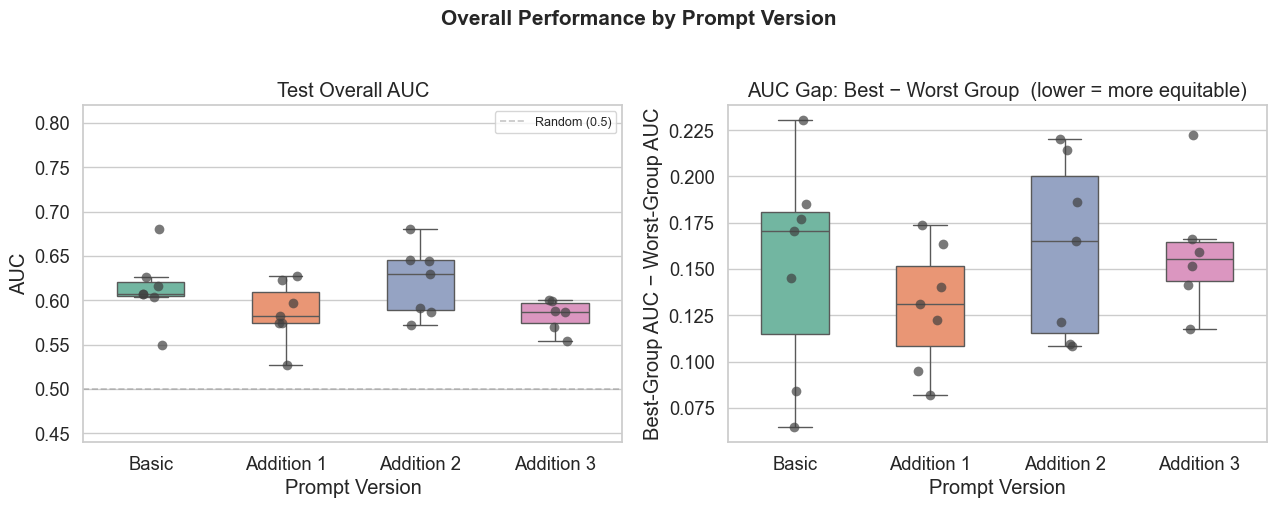

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Overall AUC ---
sns.boxplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
            palette=PALETTE, width=0.5, fliersize=0, ax=axes[0])
sns.stripplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
              color=".25", alpha=0.7, jitter=True, size=7, ax=axes[0])
axes[0].set_ylim(0.44, 0.82)
axes[0].set_xlabel("Prompt Version")
axes[0].set_ylabel("AUC")
axes[0].set_title("Test Overall AUC")
axes[0].axhline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2, label="Random (0.5)")
axes[0].legend(fontsize=9)

# --- AUC spread: best group AUC − worst group AUC ---
sns.boxplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,
            palette=PALETTE, width=0.5, fliersize=0, ax=axes[1])
sns.stripplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,
              color=".25", alpha=0.7, jitter=True, size=7, ax=axes[1])
axes[1].set_xlabel("Prompt Version")
axes[1].set_ylabel("Best-Group AUC − Worst-Group AUC")
axes[1].set_title("AUC Gap: Best − Worst Group  (lower = more equitable)")

plt.suptitle("Overall Performance by Prompt Version", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

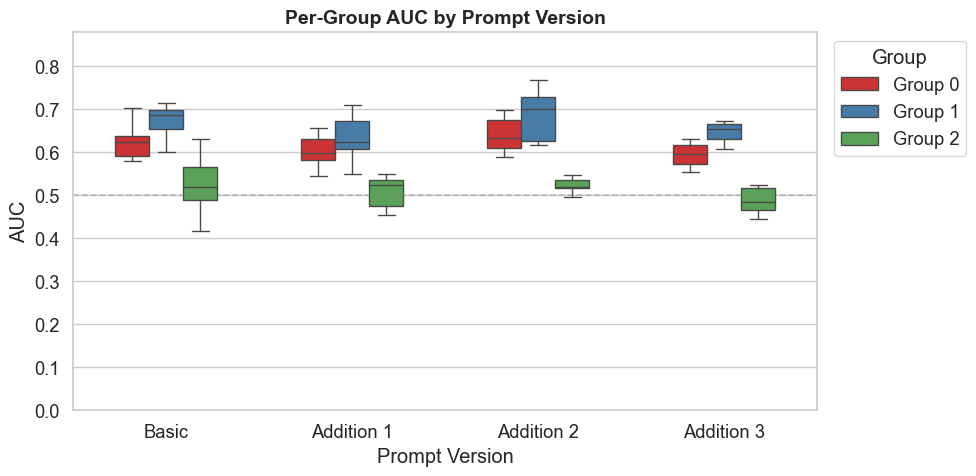

In [26]:
group_col_map = {
    "Test auc-group_0": "Group 0",
    "Test auc-group_1": "Group 1",
    "Test auc-group_2": "Group 2",
}
df_auc = (
    df[["Prompt"] + list(group_col_map.keys())]
    .melt(id_vars="Prompt", var_name="_col", value_name="AUC")
)
df_auc["Group"] = df_auc["_col"].map(group_col_map)

GROUP_PALETTE = sns.color_palette("Set1", 3)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_auc, x="Prompt", y="AUC", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=ax)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2)
ax.set_ylim(0.0, 0.88)
ax.set_xlabel("Prompt Version")
ax.set_ylabel("AUC")
ax.set_title("Per-Group AUC by Prompt Version", fontsize=14, fontweight="bold")
ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

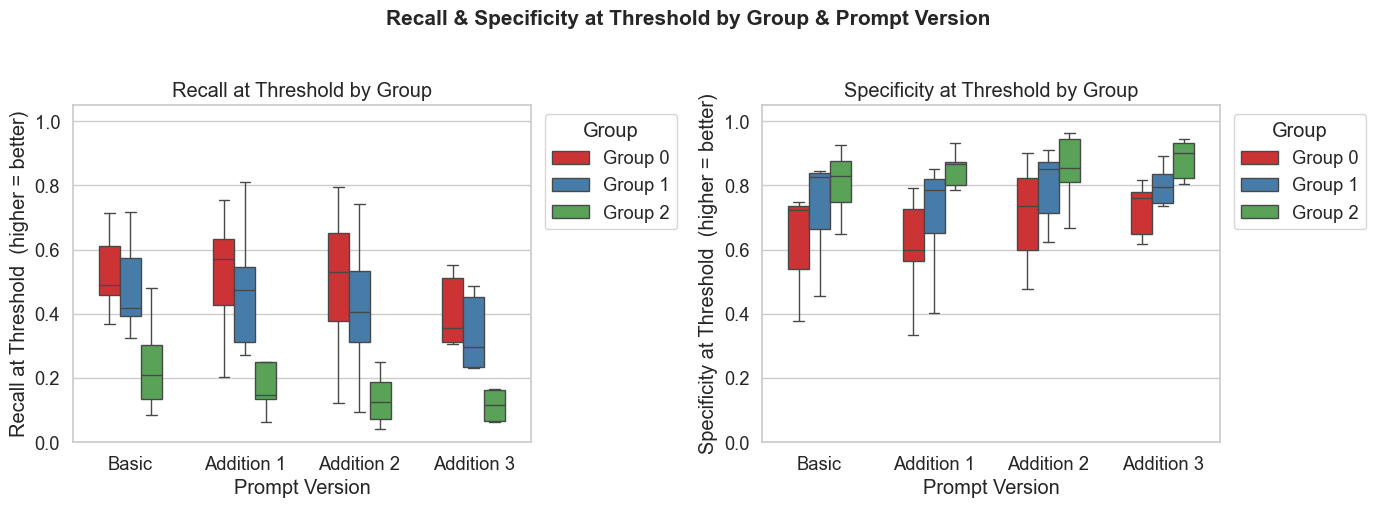

In [30]:
recall_map = {
    "Test recall_at_thres-group_0": "Group 0",
    "Test recall_at_thres-group_1": "Group 1",
    "Test recall_at_thres-group_2": "Group 2",
}
spec_map = {
    "Test specificity_at_thres-group_0": "Group 0",
    "Test specificity_at_thres-group_1": "Group 1",
    "Test specificity_at_thres-group_2": "Group 2",
}

df_recall = (
    df[["Prompt"] + list(recall_map.keys())]
    .melt(id_vars="Prompt", var_name="_c", value_name="Recall")
)
df_recall["Group"] = df_recall["_c"].map(recall_map)

df_spec = (
    df[["Prompt"] + list(spec_map.keys())]
    .melt(id_vars="Prompt", var_name="_c", value_name="Specificity")
)
df_spec["Group"] = df_spec["_c"].map(spec_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_recall, x="Prompt", y="Recall", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=axes[0])
axes[0].set_title("Recall at Threshold by Group")
axes[0].set_xlabel("Prompt Version")
axes[0].set_ylabel("Recall at Threshold  (higher = better)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")

sns.boxplot(data=df_spec, x="Prompt", y="Specificity", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=axes[1])
axes[1].set_title("Specificity at Threshold by Group")
axes[1].set_xlabel("Prompt Version")
axes[1].set_ylabel("Specificity at Threshold  (higher = better)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Recall & Specificity at Threshold by Group & Prompt Version", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

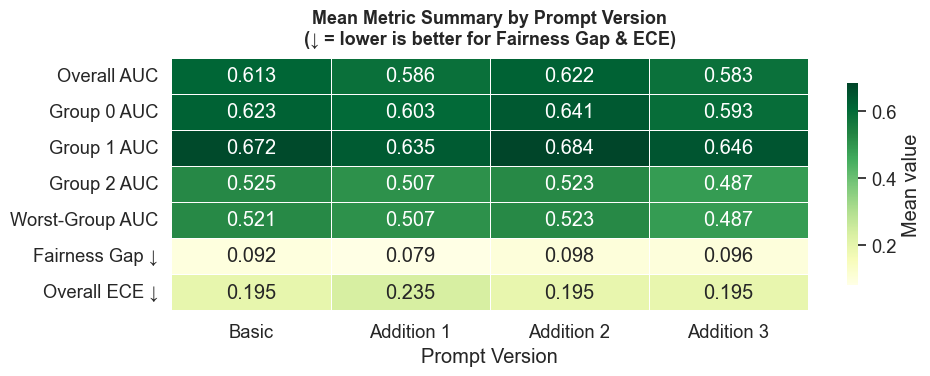

In [29]:
metric_map = {
    "Overall AUC":      "Test Overall AUC",
    "Group 0 AUC":      "Test auc-group_0",
    "Group 1 AUC":      "Test auc-group_1",
    "Group 2 AUC":      "Test auc-group_2",
    "Worst-Group AUC":  "Test worst_auc",
    "Fairness Gap ↓":   "Fairness_Gap",
    "Overall ECE ↓":    "Test Overall ECE",
}

mean_df = (
    df.groupby("Prompt")[[v for v in metric_map.values()]]
    .mean()
    .loc[PROMPT_ORDER]
)
mean_df.columns = list(metric_map.keys())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    mean_df.T, annot=True, fmt=".3f",
    cmap="YlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean value", "shrink": 0.8},
)
ax.set_title(
    "Mean Metric Summary by Prompt Version\n(↓ = lower is better for Fairness Gap & ECE)",
    fontsize=13, fontweight="bold", pad=10,
)
ax.set_xlabel("Prompt Version")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

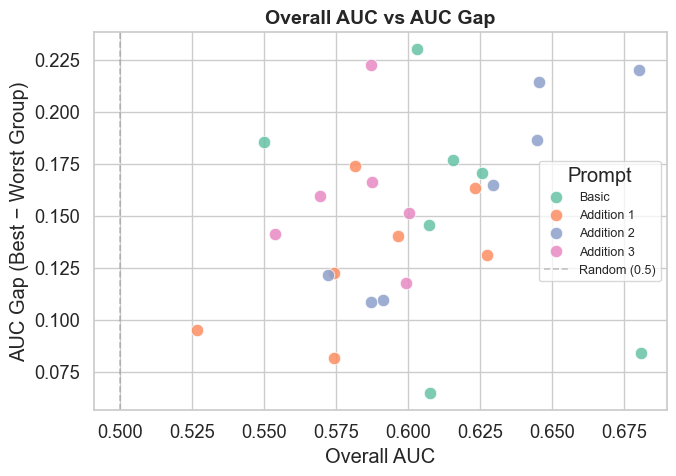

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

for prompt, color in zip(PROMPT_ORDER, PALETTE):
    sub = df[df["Prompt"] == prompt]
    ax.scatter(
        sub["Test Overall AUC"], sub["AUC_Difference"],
        label=prompt, color=color, s=80, alpha=0.85,
        edgecolors="white", linewidths=0.6, zorder=3,
    )

ax.axvline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2, label="Random (0.5)")
ax.set_xlabel("Overall AUC")
ax.set_ylabel("AUC Gap (Best − Worst Group)")
ax.set_title("Overall AUC vs AUC Gap", fontsize=14, fontweight="bold")
ax.legend(title="Prompt", fontsize=9, framealpha=0.75)
plt.tight_layout()
plt.show()